# Case 2 — Highly Heterogeneous Reservoir
## POD Analysis: Permeability Field, Pressure Response, Reduced-Order Model


In [2]:
import numpy as np
import h5py, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import UnivariateSpline
from matplotlib.ticker import LogLocator, LogFormatter
from scipy.special import expi
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import warnings
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import NullLocator

plt.rcParams.update({
    # 1. True LaTeX Font Rendering
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'], # Native LaTeX font
    
    # Optional
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}',

    # 2. Font Sizes 
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # 3. Ticks: Inward-facing and mirrored on top/right
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,

    # 4. Line and Spine Weights
    'axes.linewidth': 1,      # Frame thickness
    'lines.linewidth': 1.5,     # Data line thickness
    'lines.markersize': 6,      # Default marker size

    # 5. Grid (Keep it subtle if used)
    'axes.grid': False,
    'grid.alpha': 0.20,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,

    # 6. Saving and DPI
    'figure.dpi': 150,          # For crisp screen preview in Jupyter/Spyder
    'savefig.dpi': 600,         # High resolution for line art
    'savefig.bbox': 'tight',    # Prevents labels from getting cut off

    # legend
    # 7. Legend Formatting
    'legend.frameon': True,         
    'legend.framealpha': 1.0,       
    'legend.edgecolor': 'black',    
    'legend.fancybox': False,       
    'legend.handlelength': 1.5,     
    'legend.labelspacing': 0.4,     
    'legend.handletextpad': 0.5,    
    'legend.borderaxespad': 0.5,   

    # axes padding
    'xtick.major.pad': 5.0,  # Default is usually 3.5
    'ytick.major.pad': 5.0, 
})



# Custom Colors
C1, C2, C3, C4 = '#1a5e9e', '#0d6e56', '#9b2a1a', '#b07318'
GR = '#555555'


PROJECT = Path(r'F:\Niloy Deb\Part One\Matlab Codes\dmd_pta_rta_dt')
DATA    = PROJECT/'data'/'01_synthetic'/'case2_heterogeneous'
FIGS    = PROJECT/'figures'/'case2'
FIGS.mkdir(parents=True, exist_ok=True)
(PROJECT/'data'/'processed').mkdir(parents=True, exist_ok=True)
def sf(n): plt.savefig(FIGS/n,dpi=300,bbox_inches='tight'); print(f'  {n}')
print('Ready.')

Ready.


---
## 1 · Load Simulation Data

MRST exports `.mat` files in HDF5 format (v7.3). h5py reads arrays in C-major order, which is the transpose of MATLAB's column-major layout. Every array therefore requires `.T` immediately after loading. The additional file `rock_field.mat` contains `perm_mD` — the spatially distributed permeability field that distinguishes Case 2 from Case 1.

In [3]:
with h5py.File(DATA/'snapshots_psia.mat','r') as f:
    _raw   = np.array(f['X_psia'])          # h5py gives (N_t, N_cells) for v7.3
    X_psia = _raw.T if _raw.shape[0]<_raw.shape[1] else _raw

with h5py.File(DATA/'well_data.mat','r') as f:
    bhp_raw = np.array(f['bhp_psia']).flatten()
    dp_raw  = np.array(f['delta_p_psi']).flatten()
    qr_raw  = np.array(f['rate_STBd']).flatten()
    t_raw   = np.array(f['time_hr']).flatten()

with h5py.File(DATA/'rock_field.mat','r') as f:
    perm_mD = np.array(f['perm_mD']).flatten()

with open(DATA/'params.json') as f:
    P = json.load(f)

n_t     = min(len(t_raw), X_psia.shape[1])
t_raw   = t_raw[:n_t];  bhp_raw = bhp_raw[:n_t]
dp_raw  = dp_raw[:n_t]; qr_raw  = qr_raw[:n_t]
X_psia  = X_psia[:,:n_t]

pi_   = P['p_init_psia']
valid = (t_raw>0)&(dp_raw>0)&(dp_raw<pi_)&(bhp_raw>0)&(bhp_raw<=pi_)

t   = t_raw[valid];  dp  = dp_raw[valid]
bhp = bhp_raw[valid]; qr  = qr_raw[valid]
X   = X_psia[:,valid]

N, m  = X.shape
nx    = int(P['nx'])
ny    = int(P['ny'])
wc    = int(P['well_cell_matlab']) - 1
t_wbs = P['t_wbs_end_hr']
t_pss = P['t_pss_start_hr']

m_wbs = t < t_wbs
m_mtr = (t >= t_wbs) & (t < t_pss)
m_bdf = t >= t_pss

k_geo     = P['k_geo_mD']
sigma_lnk = P['sigma_lnk']
V_DP      = P['V_DP']

print(f'Snapshot matrix  X : {X.shape}  (cells × timesteps)')
print(f'Time range          : {t[0]:.5f} – {t[-1]:.0f} hr')
print(f'BHP range           : {bhp.min():.1f} – {bhp.max():.1f} psia')
print(f'Δp  range           : {dp.min():.4f} – {dp.max():.2f} psi')
print(f'p_init              : {pi_:.1f} psia')
print(f'WBS ends   t_WBS    : {t_wbs:.2f} hr')
print(f'PSS onset  t_PSS    : {t_pss:.1f} hr  ({t_pss/24:.1f} days)')
print(f'WBS steps           : {m_wbs.sum():4d}   ({t[m_wbs][0]:.4f} – {t[m_wbs][-1]:.3f} hr)')
print(f'MTR steps           : {m_mtr.sum():4d}   ({t[m_mtr][0]:.3f} – {t[m_mtr][-1]:.1f} hr)')
print(f'BDF steps           : {m_bdf.sum():4d}   ({t[m_bdf][0]:.1f} – {t[m_bdf][-1]:.0f} hr)')
print(f'\nPermeability field  : k_geo={k_geo:.2f} mD  σ_lnk={sigma_lnk:.3f}  V_DP={V_DP:.3f}')
print(f'  k range           : {perm_mD.min():.2f} – {perm_mD.max():.1f} mD  '
      f'(contrast~{perm_mD.max()/perm_mD.min():.0f})')

Snapshot matrix  X : (2500, 350)  (cells × timesteps)
Time range          : 0.00100 – 5000 hr
BHP range           : 4015.0 – 4361.8 psia
Δp  range           : 138.7155 – 485.55 psi
p_init              : 4500.5 psia
WBS ends   t_WBS    : 0.27 hr
PSS onset  t_PSS    : 297.2 hr  (12.4 days)
WBS steps           :  127   (0.0010 – 0.262 hr)
MTR steps           :  159   (0.274 – 295.5 hr)
BDF steps           :   64   (308.8 – 5000 hr)

Permeability field  : k_geo=21.43 mD  σ_lnk=1.887  V_DP=0.848
  k range           : 1.00 – 2000.0 mD  (contrast~2000)


---
## 2 · Permeability Field

The strongly heterogeneous log-normal permeability field $k(\mathbf{x})$ is the sole difference from Case 1. The **geometric mean** $k_{geo} = 20$ mD matches Case 1, so the theoretical PTA response (Bourdet flat level, MTR slope) is the same — but the **spatial distribution** creates preferential flow paths that break radial symmetry, increase the POD rank, and spread the DMD eigenvalue spectrum.

The **Dykstra-Parsons coefficient** $V_{DP} = 1 - e^{-\sigma_{\ln k}} = 0.865$ places this field firmly in the strongly heterogeneous category.

---
## 3 · PTA Diagnostics: $p_{wf}$ vs Log $t$ and Bourdet Derivative

### 3.1 Analytical Reference (Ei Solution)

For a heterogeneous reservoir the effective permeability $k_{eff}$ for radial flow converges to the geometric mean $k_{geo}$ (Cardwell & Parsons, 1945). The Ei solution with $k_{geo}$ therefore gives the theoretical reference. The **departure** of the simulated response from the Ei solution reflects the heterogeneity: the Bourdet derivative will not form a clean flat plateau but will show a broader, noisier radial region. The MTR straight line may be shorter or less well-defined.

In [5]:
k    = P['k_mD'];  phi_ = P['phi'];   ct  = P['ct_psi1'];  mu  = P['mu_cp']
rw   = P['rw_ft']; kh   = P['kh_mDft']; q = P['q_STBd'];  Bo  = P['Bo']
pi_  = P['p_init_psia'];  h_ft = P['h_ft'];  S_true = P['S_skin']
dp_flat = P['dp_prime_psi']
m_slope = P['m_slope_psi_cycle']

tD = 0.000264*k*t/(phi_*mu*ct*rw**2)
pD = np.where(tD>0.01, -0.5*expi(-1/(4*tD)), np.nan)
dp_ei = 141.2*q*mu*Bo/kh*pD          # Ei analytical (k_geo reference)

def bourdet(dp_arr, t_arr, L=0.2):
    n,lnt,d = len(dp_arr),np.log(t_arr),np.zeros(len(dp_arr))
    for i in range(1,n-1):
        jl=i-1
        while jl>0   and lnt[i]-lnt[jl]<L: jl-=1
        jr=i+1
        while jr<n-1 and lnt[jr]-lnt[i]<L: jr+=1
        dL,dR = lnt[i]-lnt[jl], lnt[jr]-lnt[i]
        if dL>0 and dR>0:
            d[i]=((dp_arr[i]-dp_arr[jl])/dL*dR+(dp_arr[jr]-dp_arr[i])/dR*dL)/(dL+dR)
        elif dL>0: d[i]=(dp_arr[i]-dp_arr[jl])/dL
        elif dR>0: d[i]=(dp_arr[jr]-dp_arr[i])/dR
    d[0]=(dp_arr[1]-dp_arr[0])/(lnt[1]-lnt[0])
    d[-1]=(dp_arr[-1]-dp_arr[-2])/(lnt[-1]-lnt[-2])
    return d

dpr = bourdet(dp,t)
vs  = (dpr>1e-2)&(dp>1e-2)

mtr_mask = (t>t_wbs)&(t<t_pss)
cf       = np.polyfit(np.log10(t[mtr_mask]), dp[mtr_mask], 1)
kh_est   = 162.6*q*mu*Bo/cf[0]
flat_sim = np.median(dpr[mtr_mask&vs])

print(f'MTR slope  m        : {cf[0]:.3f} psi/cycle  (theory {m_slope:.3f})')
print(f'kh estimate         : {kh_est:.1f} mD-ft       (nominal {kh:.0f})')
print(f'k_eff               : {kh_est/h_ft:.2f} mD         (k_geo {k_geo:.2f})')
print(f'Bourdet flat (sim)  : {flat_sim:.4f} psi       (theory {dp_flat:.4f})')
print(f'kh error            : {(kh_est-kh)/kh*100:.2f}%')
print(f'\nNote: departure from theory expected for V_DP={V_DP:.3f}')

MTR slope  m        : 55.740 psi/cycle  (theory 59.837)
kh estimate         : 3220.5 mD-ft       (nominal 3000)
k_eff               : 21.47 mD         (k_geo 21.43)
Bourdet flat (sim)  : 24.2578 psi       (theory 25.9808)
kh error            : 7.35%

Note: departure from theory expected for V_DP=0.848


### 3.2 Figure 2 — $p_{wf}$ vs Log $t$

### 3.3 Figure 3 — Bourdet Derivative

### 3.4 Figure 4 — Combined Diagnostic

  ch4_3_pwf_pdd_case2b.pdf


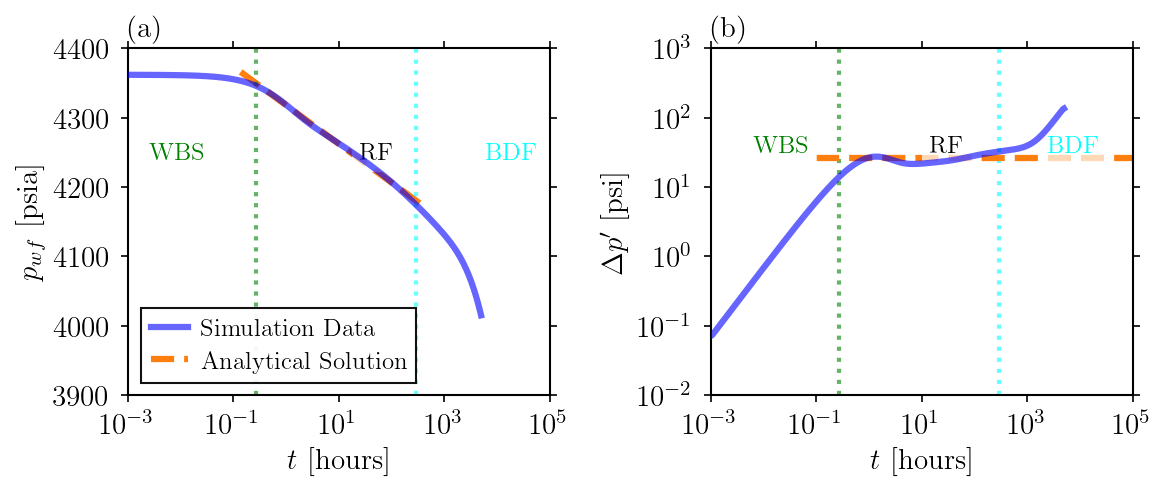

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

ax = axes[0]
ax.semilogx(t, bhp, color='b', alpha=0.6, lw=3.0,
            label='Simulation Data', zorder=4)
t_ln = np.logspace(np.log10(t[mtr_mask][0]*0.5),
                   np.log10(t[mtr_mask][-1]*1.5), 300)
ax.semilogx(t_ln, pi_ - np.polyval(cf, np.log10(t_ln)), '--',
            color='C1', lw=3, label='Analytical Solution')
ax.axvline(t_pss, color='cyan', lw=2, ls=':', alpha=0.6)
ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.6)
ax.text(0.05, 0.73, 'WBS', transform=ax.transAxes, fontsize=12, color='green',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.55, 0.73, 'RF', transform=ax.transAxes, fontsize=12, color='black',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.85, 0.73, 'BDF', transform=ax.transAxes, fontsize=12, color='cyan',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.set_title('(a)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel('$p_{wf}$ [psia]')
ax.set_xlim([0.001, 100000])
ax.set_ylim([3900, 4400])
ax.legend(loc='lower left', framealpha=0.93, fontsize=12)

ax = axes[1]
ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.6)
ax.axvline(t_pss, color='cyan', lw=2, ls=':', alpha=0.6)
ax.loglog(t[vs], dpr[vs], color='b', alpha=0.6, lw=3.0,
          label='Simulation Data', zorder=4)
ax.loglog([0.1, 100000], [dp_flat, dp_flat], '--', color='C1', lw=3,
          label='Analytical Solution')
ax.text(0.1, 0.75, 'WBS', transform=ax.transAxes, fontsize=12, color='green',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.52, 0.75, 'RF', transform=ax.transAxes, fontsize=12, color='black',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.80, 0.75, 'BDF', transform=ax.transAxes, fontsize=12, color='cyan',
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())
ax.set_title('(b)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel(r"$\Delta p'$ [psi]")
ax.set_xlim([0.001, 100000])
ax.set_ylim([0.01, 1000])

plt.tight_layout()
#sf('fig2_hetero_pwf_dpp.pdf')
sf('ch4_3_pwf_pdd_case2b.pdf')
plt.show()

---
## 4 · Pressure Field Visualisation

The drawdown field $\Delta p(\mathbf{x},t) = p_i - p(\mathbf{x},t)$ is plotted rather than absolute pressure. For a strongly heterogeneous reservoir ($V_{DP}=0.865$) the field is **markedly non-radial** — high-permeability channels deplete faster, creating elongated pressure funnels aligned with the permeability structure. Compare with Case 1: the circular contours seen there are replaced by irregular, channel-following wavefronts. This spatial complexity is what drives the higher POD rank.

  fig3_hetero_pressure_fields.pdf


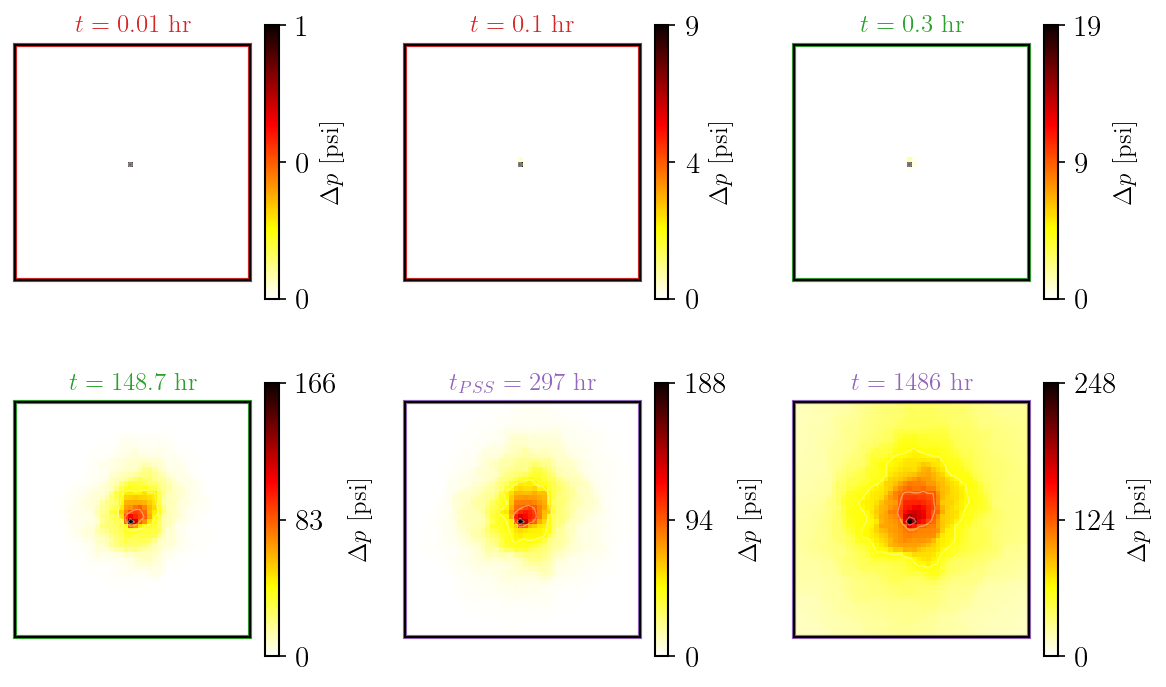

In [9]:
dX = P['p_init_psia'] - X    # drawdown field (N_cells, N_t)

def snap_idx(t_target):
    return int(np.argmin(np.abs(t - t_target)))

snaps = [
    (snap_idx(0.01),                   f'$t = 0.01$ hr',                  'C3'),
    (snap_idx(t_wbs/2),               f'$t = {t_wbs/2:.1f}$ hr',        'C3'),
    (snap_idx(t_wbs*1.2),             f'$t = {t_wbs*1.2:.1f}$ hr',      'C2'),
    (snap_idx((t_wbs+t_pss)/2),       f'$t = {(t_wbs+t_pss)/2:.1f}$ hr','C2'),
    (snap_idx(t_pss),                 f'$t_{{PSS}} = {t_pss:.0f}$ hr',  'C4'),
    (snap_idx(min(t_pss*5,t[-1])),    f'$t = {min(t_pss*5,t[-1]):.0f}$ hr','C4'),
]

fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for ax,(ki,ttl,col) in zip(axes.flat, snaps):
    F  = dX[:,ki].reshape(ny,nx)
    vm = max(F.max(), 0.1)
    im = ax.imshow(F, origin='lower', cmap='hot_r',
                   vmin=0, vmax=vm, aspect='equal')
    # ax.plot(nx//2-0.5, ny//2-0.5, '+', color='white',
    #         ms=12, mew=2.5, zorder=10)
    for lp in [0.25,0.50,0.75]:
        lv=vm*lp
        if lv>0.05:
            ax.contour(F,levels=[lv],colors=['w'],
                       linewidths=0.6,alpha=0.4)
    ax.set_title(ttl, fontsize=12, color=col, fontweight='normal')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.add_patch(plt.Rectangle((0,0),1,1,fill=False,ec=col,lw=2,
                               transform=ax.transAxes,clip_on=False))
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    cb.set_ticks([0, vm/2, vm])
    cb.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))
    cb.set_label(r'$\Delta p$ [psi]', fontsize=12)
    #ax.text(0.97,0.03,f'max = {vm:.0f} psi',
            #transform=ax.transAxes,fontsize=11,
           # ha='right',va='bottom',color='white',family='monospace',
           # bbox=dict(fc='k',alpha=0.6,pad=1.5,ec='none'))

plt.tight_layout()
sf('ch4_8_p_field_case2.pdf')
plt.show()

---
## 5 · Proper Orthogonal Decomposition (POD)

The snapshot matrix $\mathbf{X} \in \mathbb{R}^{N\times m}$ ($N$ = number of grid cells, $m$ = number of timesteps) is mean-centred before decomposition:

$$\mathbf{X}_c = \mathbf{X} - \bar{\mathbf{x}}\mathbf{1}^T, \qquad\mathbf{X}_c = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$$

**Expected differences from Case 1 (homogeneous):**

- **Slower singular value decay** — heterogeneity generates independent spatial depletion patterns at multiple scales.
- **Smaller spectral gap** $\sigma_2/\sigma_1$ — no single mode captures all the variance as cleanly as in the radially symmetric case.
- **Higher $r_{99.9\%}$** — more modes needed to represent the field. For $V_{DP}=0.865$ expect $r_{99.9\%} \sim 8$–15, vs $r=2$–3 for Case 1.
- **Non-circular mode shapes** — modes $\mathbf{u}_i(\mathbf{x})$ reflect the dominant channels and barriers rather than concentric rings.

In [10]:
X_mean = X.mean(axis=1, keepdims=True)
Xc     = X - X_mean
U, sv, Vt = np.linalg.svd(Xc, full_matrices=False)

sn  = sv / sv[0]                                # normalised singular values
cum = np.cumsum(sv**2) / np.sum(sv**2) * 100    # cumulative energy

r99   = int(np.searchsorted(cum, 99.0)) + 1
r999  = int(np.searchsorted(cum, 99.94)) + 1
r_sel = max(r999, 2)

print(f'Snapshot matrix      : {X.shape}')
print(f'σ₁                   : {sv[0]:.2f} psia')
print(f'σ₂/σ₁                : {sn[1]:.3e}  (spectral gap)')
print(f'r for 99.0%% energy  : {r99}')
print(f'r for 99.9%% energy  : {r999}  ← selected r = {r_sel}')
print('\nModal energy breakdown:')
for i in range(min(6,len(sv))):
    print(f'  Mode {i+1}  σ={sv[i]:.2f}  σᵢ/σ₁={sn[i]:.2e}  '
          f'cumE={cum[i]:.5f}%')

Snapshot matrix      : (2500, 350)
σ₁                   : 23202.03 psia
σ₂/σ₁                : 2.197e-01  (spectral gap)
r for 99.0%% energy  : 2
r for 99.9%% energy  : 4  ← selected r = 4

Modal energy breakdown:
  Mode 1  σ=23202.03  σᵢ/σ₁=1.00e+00  cumE=95.02015%
  Mode 2  σ=5096.87  σᵢ/σ₁=2.20e-01  cumE=99.60548%
  Mode 3  σ=1359.64  σᵢ/σ₁=5.86e-02  cumE=99.93178%
  Mode 4  σ=539.31  σᵢ/σ₁=2.32e-02  cumE=99.98312%
  Mode 5  σ=257.21  σᵢ/σ₁=1.11e-02  cumE=99.99480%
  Mode 6  σ=146.13  σᵢ/σ₁=6.30e-03  cumE=99.99857%


### 5.1 Figure 6 — Singular Value Spectrum and Cumulative Energy

  fig4_hetero_svd_spectrum.pdf


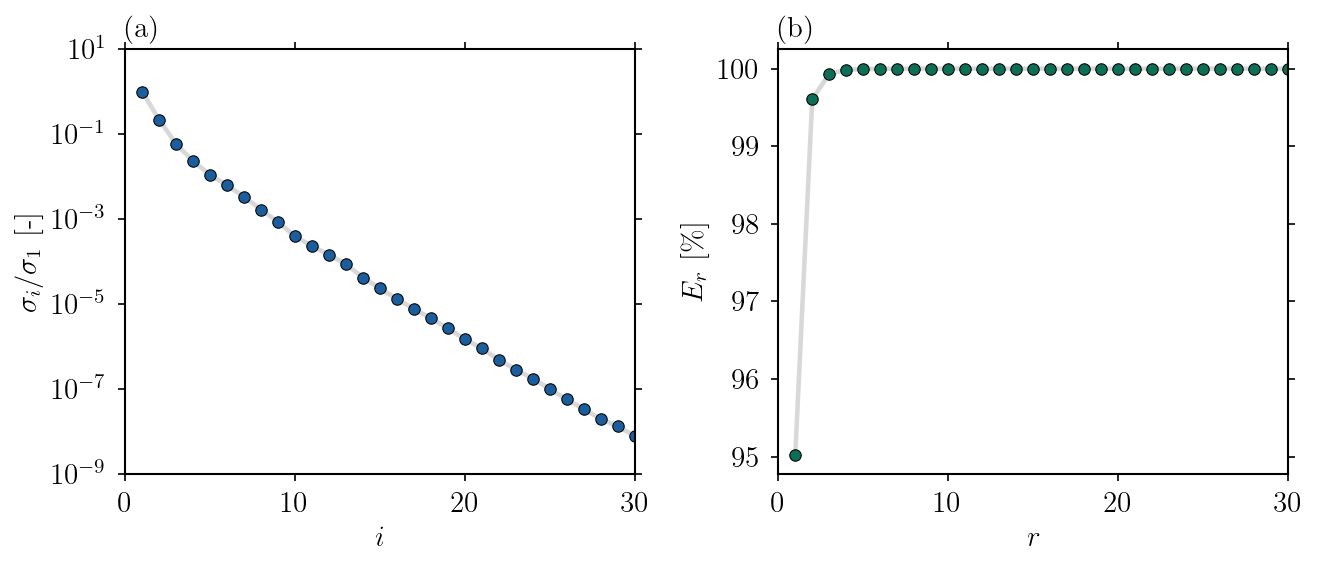

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

ax = axes[0]
ax.semilogy(range(1,31), sn[:30], 'o', color=C1, ms=5.5, mec='k', mew=0.5)
ax.semilogy(range(1, 31), sn[:30], color='gray', alpha=0.3, lw=2.2, zorder=1)
ax.set_title('(a)', loc='left', fontweight='normal')
ax.set_xlabel('$i$')
ax.set_ylabel(r'$\sigma_i / \sigma_1$ [-]')
ax.set_xlim([0,30])
ax.set_ylim(1e-9, 10)
# for idx, col in [(0,'C3'), (1,'C0'), (2,'C5'), (3,'C8')]:
#     ax.axvline(idx+1, color=col, ls=':', lw=1.5)
#     ax.text(idx+1, sn[min(idx, len(sn)-1)]*0.2,
#             f'$i={idx+1}$', color=col, rotation=90,
#             ha='right', va='center', fontweight='bold',
#             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))


ax2 = axes[1]
ax2.plot(range(1,31), cum[:30], 'o', color=C2, ms=5.5, mec='k', mew=0.5)
ax2.plot(range(1,31), cum[:30], color='gray', alpha=0.3, lw=2.2, zorder=1)
ax2.set_title('(b)', loc='left', fontweight='normal')
ax2.set_xlabel('$r$')
ax2.set_ylabel(r'$E_r \ [\%]$')
ax2.set_xlim([0,30])
x_positions = [16, 16, 16, 6]   

# for idx, col in [(0,'C3'), (1,'C0'), (2,'C5'), (3,'C8')]:
#     if idx < len(cum):
#         ax2.axhline(cum[idx], color=col, ls=':', lw=1.5)
#         ax2.text(x_positions[idx], cum[idx],
#                  f'$r={idx+1}\\ (E_r={cum[idx]:.2f}\\%)$',
#                  color=col, ha='center', va='top', fontweight='bold',
#                  bbox=dict(facecolor='none', edgecolor='none', alpha=0.8, pad=1))

plt.tight_layout()
sf('ch5_5_svd_rank_case2.pdf')
plt.show()

### 5.2 Figure 7 — POD Spatial Modes $\mathbf{u}_i(\mathbf{x})$ and Temporal Coefficients $a_i(t)$

Each mode $\mathbf{u}_i$ is a unit-norm dimensionless vector ($\|\mathbf{u}_i\|_2=1$); the pressure scale is carried by $\sigma_i$ [psia]. The temporal coefficient $a_i(t) = \sigma_i v_i(t)$ is colour-coded: blue = radial flow, amber = BDF. Unlike Case 1, the mode shapes are **not radially symmetric** — they trace the dominant flow paths in the heterogeneous permeability field.

  ch5_6_pod_modes_case2.pdf


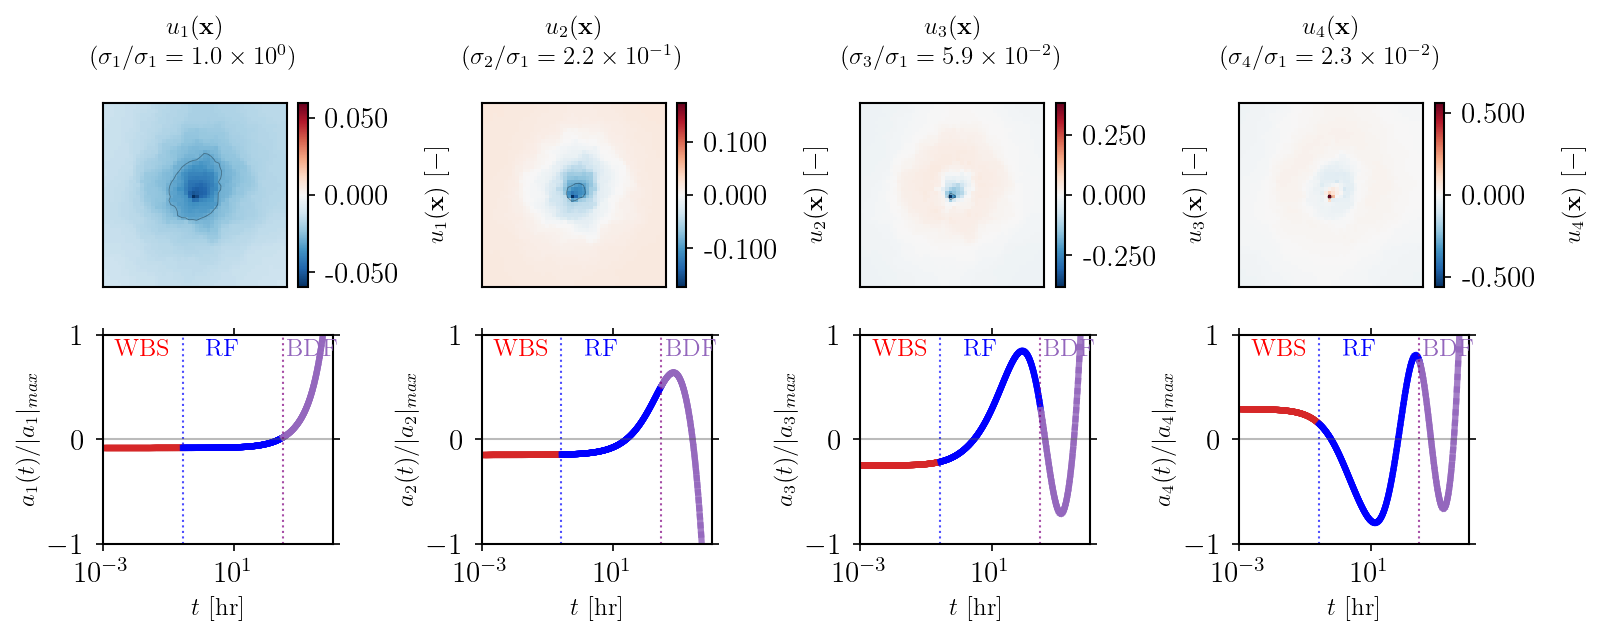

In [13]:
n_show = min(4, r_sel)
# Increased figsize slightly to accommodate the larger font sizes
fig, axes = plt.subplots(2, n_show, figsize=(11, 4.5))
if n_show==1: axes=axes.reshape(2,1)

mode_phys = ['Effective depletion\n(dominant)',
             'Heterogeneity\ncorrection',
             'Channel / barrier\nstructure',
             'Higher-order\ncorrection']

for i in range(n_show):
    # --- spatial mode ---
    ax = axes[0,i]
    ui = U[:,i].reshape(ny,nx)
    vm = np.abs(ui).max()
    im = ax.imshow(ui, origin='lower', cmap='RdBu_r',
                   vmin=-vm, vmax=vm, aspect='equal')
    m_val = f'{sn[i]:.1e}'.split('e')[0]
    e_val = int(f'{sn[i]:.1e}'.split('e')[1])
    
    #ax.plot(nx//2,ny//2,'k+',ms=10,mew=2.5,zorder=10)
    ax.contour(np.abs(ui),levels=[vm*0.5],colors=['k'],
               linewidths=0.4,alpha=0.35)
    ax.set_title(
        f'${{u}}_{{{i+1}}}(\\mathbf{{x}})$\n'
        f'$(\\sigma_{{{i+1}}}/\\sigma_1={m_val}\\times10^{{{e_val}}})$\n', fontsize=12)
        
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    plt.colorbar(im,ax=ax,shrink=0.88,format='%.3f').set_label(
        rf'$u_{i+1}(\mathbf{{x}})\ [-]$',
        fontsize=12, rotation=90, labelpad=12)

    # --- temporal coefficient ---
    ax2 = axes[1,i]
    ai   = sv[i]*Vt[i,:]
    ai_n = ai/np.abs(ai).max()
    
    # 1. Colors strictly matched to Case 3 (C3 for WBS, blue for RF, C4 for BDF)
    col_seg = ['C3' if ti < t_wbs else 'blue' if ti < t_pss else 'C4' for ti in t]
    
    for j in range(len(t)-1):
        ax2.semilogx(t[j:j+2],ai_n[j:j+2],
                     color=col_seg[j],lw=3,alpha=0.85)
                     
    # 2. Vertical lines matched to Case 3
    ax2.axvline(t_wbs, color='blue', lw=1.0, ls=':', alpha=0.7)
    ax2.axvline(t_pss, color='purple', lw=1.0, ls=':', alpha=0.7)
    
    ax2.axhline(0,color=GR,lw=1.0,alpha=0.4)
    ax2.set_xlabel('$t$ [hr]',fontsize=12)
    ax2.set_ylabel(f'$a_{i+1}(t)/|a_{i+1}|_{{max}}$',fontsize=12)
    ax2.set_xlim(0.001,10000); ax2.set_ylim([-1,1])
    
    # 3. Text colors strictly matched to Case 3
    ax2.text(0.05, 0.9, 'WBS', transform=ax2.transAxes, color='red', fontweight='normal', fontsize=12)
    ax2.text(0.45, 0.9, 'RF', transform=ax2.transAxes, color='blue', fontweight='normal', fontsize=12)
    ax2.text(0.80, 0.9, 'BDF', transform=ax2.transAxes, color='C4', fontweight='normal', fontsize=12)

plt.tight_layout()
#sf('fig5_hetero_pod_modes_temporal.pdf')
sf('ch5_6_pod_modes_case2.pdf')
plt.show()

  ch6_2_ssa_case2.pdf


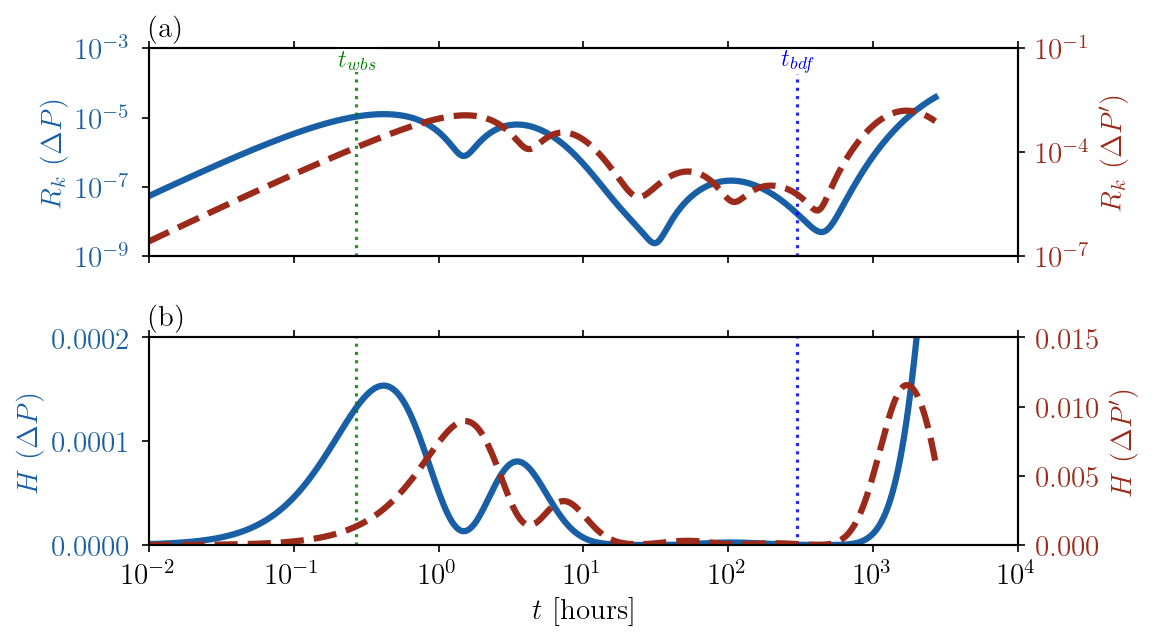

In [25]:
# =============================================================================
# SECTION 1: UNIFORM LOG-TIME RESAMPLING
# =============================================================================
dp_bhp   = P['p_init_psia'] - bhp
tau      = np.log(t)
tau_uni  = np.linspace(tau.min(), tau.max(), 500)
t_uni    = np.exp(tau_uni)

f_interp = interp1d(tau, dp_bhp, kind='cubic')
dp_uni   = f_interp(tau_uni)
dpr_uni  = np.gradient(dp_uni, tau_uni)

# =============================================================================
# SECTION 2: HANKEL EMBEDDING — built for both signals
# =============================================================================
def _build_hankel(signal, d):
    n = len(signal)
    H = np.zeros((d, n - d))
    for i in range(d):
        H[i, :] = signal[i : n - d + i]
    return H

d_h    = 20
W_h    = 40
k_rank = 3

H_dp  = _build_hankel(dp_uni,  d_h)   # from ΔP
H_dpr = _build_hankel(dpr_uni, d_h)   # from ΔP'

m_Hank = H_dp.shape[1]                # 500 - d_h = 480
t_Hank = t_uni[d_h:]                  # exactly m_Hank entries

# =============================================================================
# SECTION 3: SLIDING SSA — runs for both Hankel matrices
# =============================================================================
def _sliding_ssa(H_mat, t_Hank, W_h, k_rank):
    m      = H_mat.shape[1]
    n_h    = m - W_h
    t_str  = np.zeros(n_h)
    Rk     = np.zeros(n_h)
    H_ent  = np.zeros(n_h)

    for k_s in range(n_h):
        Xw          = H_mat[:, k_s : k_s + W_h]
        t_str[k_s]  = t_Hank[k_s + W_h // 2]

        try:
            _, S_w, _       = np.linalg.svd(Xw, full_matrices=False)
            energies        = S_w ** 2
            E_primary       = energies[0]

            Rk[k_s]         = np.sum(energies[1:k_rank]) / E_primary

            e_trunc         = energies[energies > 1e-10 * E_primary]
            p_i             = e_trunc / e_trunc.sum()
            H_ent[k_s]      = -np.sum(p_i * np.log(p_i))

        except Exception:
            Rk[k_s]    = np.nan
            H_ent[k_s] = np.nan

    return t_str, Rk, H_ent

t_stream_dp,  Rk_dp,  H_dp_ent  = _sliding_ssa(H_dp,  t_Hank, W_h, k_rank)
t_stream_dpr, Rk_dpr, H_dpr_ent = _sliding_ssa(H_dpr, t_Hank, W_h, k_rank)

# =============================================================================
# SECTION 4: SMOOTHING
# =============================================================================
def _smooth(arr):
    valid = np.isfinite(arr)
    n     = valid.sum()
    win   = 31 if n > 31 else (n // 2) * 2 - 1
    out   = np.full(len(arr), np.nan)
    out[valid] = savgol_filter(arr[valid], window_length=win, polyorder=3)
    return out, valid

H_dp_smooth,  v_dp  = _smooth(H_dp_ent)
H_dpr_smooth, v_dpr = _smooth(H_dpr_ent)

# valid masks for Rk (raw, no smoothing)
vr_dp  = np.isfinite(Rk_dp)
vr_dpr = np.isfinite(Rk_dpr)

# Stable radial flow: minimum Rk for each signal
idx_dp  = np.argmin(Rk_dp[vr_dp])
idx_dpr = np.argmin(Rk_dpr[vr_dpr])
t_stable_dp  = t_stream_dp[vr_dp][idx_dp]
t_stable_dpr = t_stream_dpr[vr_dpr][idx_dpr]

# =============================================================================
# SECTION 5: PLOTTING
# =============================================================================
# Color palette
C_dp  = '#185FA5'   # blue  — ΔP
C_dpr = '#9b2a1a'   # red   — ΔP'

ref_events = [(t_wbs, 'green', r'$t_{wbs}$'),
              (t_pss, 'blue',  r'$t_{bdf}$')]

fig, axes = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
fig.subplots_adjust(hspace=0.08)

# --- (a) Multi-Rank Complexity Rk — twin y axes ---
ax1      = axes[0]
ax1_twin = ax1.twinx()

ax1.loglog     (t_stream_dp[vr_dp],   Rk_dp[vr_dp],   color=C_dp,  lw=3.0, label=r'$R_k$ ($\Delta P$)')
ax1_twin.loglog(t_stream_dpr[vr_dpr], Rk_dpr[vr_dpr], color=C_dpr, lw=3.0, label=r"$R_k$ ($\Delta P'$)", ls='--')

# t_stable markers
#ax1.scatter     (t_stable_dp,  Rk_dp[vr_dp][idx_dp],   color=C_dp,  s=60, zorder=5, marker='v')
#ax1_twin.scatter(t_stable_dpr, Rk_dpr[vr_dpr][idx_dpr], color=C_dpr, s=60, zorder=5, marker='v')

ax1.set_ylabel     (r'$R_k$  ($\Delta P$)',  color=C_dp)
ax1_twin.set_ylabel(r"$R_k$  ($\Delta P'$)", color=C_dpr)
ax1.tick_params(axis='y', labelcolor=C_dp)
ax1_twin.tick_params(axis='y', labelcolor=C_dpr)
ax1.set_ylim([1e-9, 1e-3])
ax1_twin.set_ylim([1e-7, 1e-1])
ax1.set_title('(a)', loc='left')
ax1.xaxis.set_minor_locator(NullLocator())
ax1.yaxis.set_minor_locator(NullLocator())
ax1_twin.yaxis.set_minor_locator(NullLocator())
# combined legend
lines  = ax1.get_lines()      + ax1_twin.get_lines()
labels = [l.get_label() for l in lines]
#ax1.legend(lines, labels, fontsize=11, framealpha=0.4, loc='upper left')

# --- (b) Spectral Entropy H — twin y axes ---
ax2      = axes[1]
ax2_twin = ax2.twinx()

ax2.semilogx     (t_stream_dp[v_dp],   H_dp_smooth[v_dp],   color=C_dp,  lw=3.0, label=r'$H$ ($\Delta P$)')
ax2_twin.semilogx(t_stream_dpr[v_dpr], H_dpr_smooth[v_dpr], color=C_dpr, lw=3.0, label=r"$H$ ($\Delta P'$)", ls='--')

ax2.set_ylabel     (r'$H$  ($\Delta P$)',  color=C_dp)
ax2_twin.set_ylabel(r"$H$  ($\Delta P'$)", color=C_dpr)
ax2.tick_params(axis='y', labelcolor=C_dp)
ax2_twin.tick_params(axis='y', labelcolor=C_dpr)
ax2.set_xlabel(r'$t$  [hours]')
ax2.set_title('(b)', loc='left')
ax2.set_ylim([0, 0.0002])
ax2_twin.set_ylim([0, 0.015])
ax2.xaxis.set_minor_locator(NullLocator())
ax2.yaxis.set_minor_locator(NullLocator())

lines2  = ax2.get_lines()      + ax2_twin.get_lines()
labels2 = [l.get_label() for l in lines2]
#ax2.legend(lines2, labels2, fontsize=11, framealpha=0.4, loc='upper left')

# --- shared decorations ---
for ax_s in [ax1, ax2]:
    for tv, col, _ in ref_events:
        ax_s.axvline(tv, color=col, lw=1.5, ls=':', alpha=0.85)

for tv, col, lbl in ref_events:
    ax1.text(tv, 0.92, lbl,
             transform  = ax1.get_xaxis_transform(),
             fontsize=12, ha='center', color=col, fontweight='normal',
             bbox=dict(facecolor='white', edgecolor='none', pad=1.0))

ax1.set_xlim([0.01, 1e4])

plt.tight_layout()
sf('ch6_2_ssa_case2.pdf')
plt.show()

---
## 7 · Reduced-Order Model (ROM) Reconstruction

The ROM is based on the **Proper Orthogonal Decomposition** (POD) truncated reconstruction. From the SVD $\mathbf{X}_c = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$, the rank-$r$ optimal approximation is given by the **Eckart–Young theorem**:

$$\hat{\mathbf{X}} = \mathbf{U}_r\boldsymbol{\Sigma}_r\mathbf{V}_r^T + \bar{\mathbf{x}}\mathbf{1}^T$$

The global reconstruction error is exactly the discarded energy:

$$\varepsilon_G(r) = \frac{\sqrt{\sum_{i=r+1}^{\min(N,m)}\sigma_i^2}}{\|\mathbf{X}\|_F}\times100\%$$

The ROM BHP is recovered by applying the Peaceman + skin correction:

$$\hat{p}_{wf}(t) = \hat{p}_{cell}(t) - \Delta p_{Peaceman+skin}$$

Because Case 2 has higher intrinsic dimensionality than Case 1, a **higher rank** is needed to achieve the same reconstruction accuracy. This is the quantitative demonstration that heterogeneity increases the complexity of the ROM required to faithfully represent the reservoir.

In [16]:
X_rom = U[:,:r_sel] @ np.diag(sv[:r_sel]) @ Vt[:r_sel,:] + X_mean

eps_t = (np.linalg.norm(X-X_rom,axis=0) /
         np.linalg.norm(X,       axis=0) * 100)
eps_g =  np.linalg.norm(X-X_rom,'fro') / np.linalg.norm(X,'fro') * 100

print(f'ROM rank r            : {r_sel}')
print(f'Global L² error ε_G   : {eps_g:.4f}%')
print(f'Max per-step error    : {eps_t.max():.4f}%')
print(f'Mean per-step error   : {eps_t.mean():.4f}%')
print(f'BHP ROM range         : {X_rom[wc,:].min():.1f} – {X_rom[wc,:].max():.1f} psia')
print(f'(global error = POD truncation error: 100×sqrt(Σσ²_r+1/Σσ²_all))')

ROM rank r            : 4
Global L² error ε_G   : 0.0074%
Max per-step error    : 0.0245%
Mean per-step error   : 0.0065%
BHP ROM range         : 4167.6 – 4494.4 psia
(global error = POD truncation error: 100×sqrt(Σσ²_r+1/Σσ²_all))


### 7.1 Figure 10 — ROM Reconstruction Quality vs Rank

k_well_cell   : 45.12 mD  (k_geo = 21.43 mD)
kh_well_cell  : 6768.0 mD-ft
dp_correction : 138.9 psia
  ch5_7_pwf_dp_recon_case2.pdf


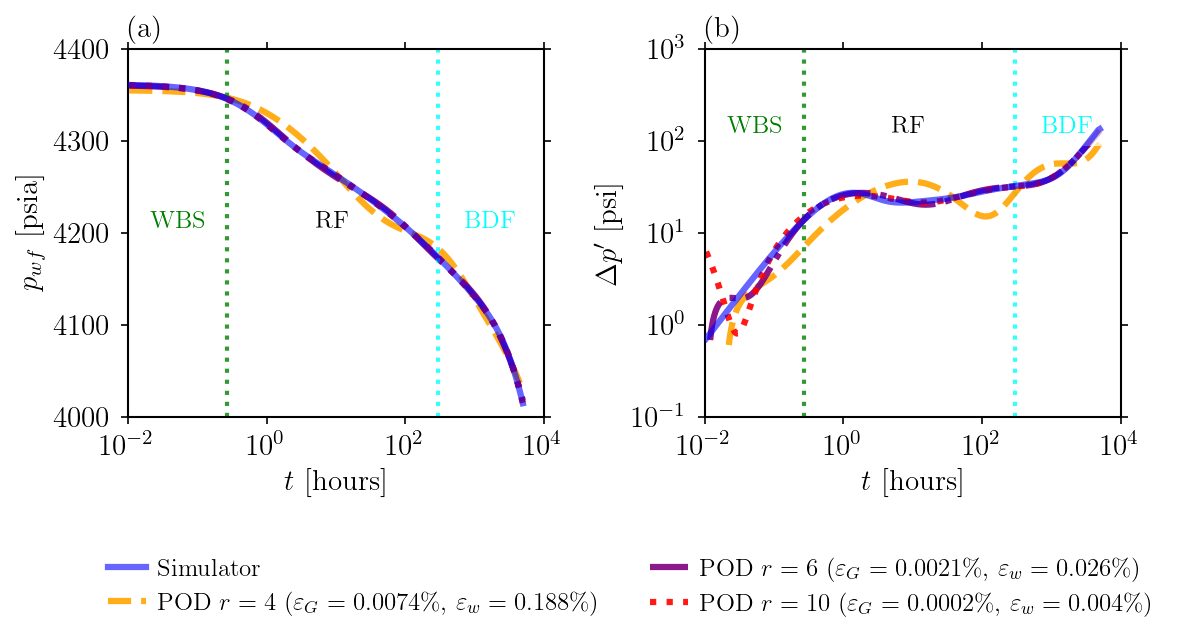

Peaceman+skin offset  : 138.9 psia
BHP comparison window : t > 0.27 hr  (after WBS ends)

   r           ε_G        ε_well     max|err| [psia]
────────────────────────────────────────────────────
   4       0.0074%        0.188%             15.97
   6       0.0021%        0.026%              3.07
  10       0.0002%        0.004%              0.40


In [18]:
# ── Peaceman + skin correction ─────────────────────────────────────────────
r_eq_ft       = 0.2 * P['dx_ft']

# use actual well-cell permeability — not k_geo — to match MRST internal Peaceman
kh_well_cell  = P['k_well_cell_mD'] * P['h_ft']   # mD-ft at well cell

dp_correction = (141.2 * P['q_STBd'] * P['mu_cp'] * P['Bo'] / kh_well_cell
                 * (np.log(r_eq_ft / P['rw_ft']) + P['S_skin']))

print(f'k_well_cell   : {P["k_well_cell_mD"]:.2f} mD  (k_geo = {P["k_geo_mD"]:.2f} mD)')
print(f'kh_well_cell  : {kh_well_cell:.1f} mD-ft')
print(f'dp_correction : {dp_correction:.1f} psia')

ranks  = [4, 6, 10]
colors = ['orange', 'purple', 'red']
styles = ['--', '-.', ':']

# ── time windows ───────────────────────────────────────────────────────────
t_lo, t_hi = 0.01, 1e4
t_mask = (t >= t_lo) & (t <= t_hi)
lnt    = np.log(t)

# full time mask for Bourdet panel (b) — start at 0.1 hr to show WBS
t_lo_b = 0.01
t_mask_b = (t >= t_lo_b) & (t <= t_hi)

# ── simulator ─────────────────────────────────────────────────────────────
bhp_sim = bhp
dp_sim  = P['p_init_psia'] - bhp_sim
dpr_sim = bourdet(np.clip(dp_sim, 0, None), t, L=0.2)
vs_sim  = t_mask_b & (dp_sim > 0.5) & (dpr_sim > 0.5)

# ── ROM quantities for all ranks ───────────────────────────────────────────
rom_data = {}
for r in ranks:
    X_r      = U[:, :r] @ np.diag(sv[:r]) @ Vt[:r, :] + X_mean
    bhp_r_wf = X_r[wc, :] - dp_correction
    dp_r     = P['p_init_psia'] - bhp_r_wf

    vf      = t_mask_b & (dp_r > 0.5) & np.isfinite(dp_r)
    spl     = UnivariateSpline(lnt[vf], dp_r[vf], k=5, s=vf.sum() * 0.3)
    dp_spl  = np.clip(spl(lnt),              0, None)
    dpr_spl = np.clip(spl.derivative()(lnt), 0, None)
    vs_r    = t_mask_b & (dp_spl > 0.5) & (dpr_spl > 0.5)

    eps_g_r = (np.linalg.norm(X - X_r, 'fro') /
               np.linalg.norm(X, 'fro') * 100)
    eps_local = (np.linalg.norm(bhp_sim[t_mask] - bhp_r_wf[t_mask]) /
                 np.linalg.norm(bhp_sim[t_mask]) * 100)

    rom_data[r] = dict(bhp_wf=bhp_r_wf, dp_spl=dp_spl, dpr_spl=dpr_spl,
                       vs=vs_r, eg=eps_g_r, el=eps_local)

# ── regime label x-positions ───────────────────────────────────────────────
log_lo    = np.log10(t_lo)
log_range = np.log10(t_hi) - log_lo
def xpos(t_val):
    return (np.log10(np.clip(t_val, t_lo, t_hi)) - log_lo) / log_range

wbs_x = xpos(np.sqrt(t_lo  * t_wbs))
rf_x  = xpos(np.sqrt(t_wbs * t_pss))
bdf_x = xpos(np.sqrt(t_pss * t_hi))

# x-positions for Bourdet panel (b) — different t_lo
log_lo_b    = np.log10(t_lo_b)
log_range_b = np.log10(t_hi) - log_lo_b
def xpos_b(t_val):
    return (np.log10(np.clip(t_val, t_lo_b, t_hi)) - log_lo_b) / log_range_b

wbs_x_b = xpos_b(np.sqrt(t_lo_b * t_wbs))
rf_x_b  = xpos_b(np.sqrt(t_wbs  * t_pss))
bdf_x_b = xpos_b(np.sqrt(t_pss  * t_hi))

# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# ── panel (a): BHP ────────────────────────────────────────────────────────
ax = axes[0]

ax.semilogx(t[t_mask], bhp_sim[t_mask],
            color='blue', alpha=0.6, lw=3.0, label='Simulator', zorder=4)

for r, col, ls in zip(ranks, colors, styles):
    d = rom_data[r]
    ax.semilogx(t[t_mask], d['bhp_wf'][t_mask],
                color=col, lw=3.0, ls=ls, alpha=0.90,
                label=(rf'POD  $r={r}$  '
                       rf'($\varepsilon_G={d["eg"]:.4f}\%$, '
                       rf'$\varepsilon_{{w}}={d["el"]:.3f}\%$)'))

ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.8)
ax.axvline(t_pss, color='cyan',  lw=2, ls=':', alpha=0.8)

for xp, lbl, color_name in [(wbs_x, 'WBS', 'green'), (rf_x, 'RF', 'black'), (bdf_x, 'BDF', 'cyan')]:
    ax.text(xp, 0.56, lbl, transform=ax.transAxes, fontsize=12,
            color=color_name, ha='center', verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_title('(a)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel('$p_{wf}$ [psia]')
ax.set_xlim([t_lo, t_hi])
ax.set_ylim([4000, 4400])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# ── panel (b): Bourdet derivative ─────────────────────────────────────────
ax2 = axes[1]

ax2.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.8)
ax2.axvline(t_pss, color='cyan',  lw=2, ls=':', alpha=0.8)

ax2.loglog(t[vs_sim], dpr_sim[vs_sim],
           color='blue', alpha=0.6, lw=3.0, label='Simulator', zorder=4)

for r, col, ls in zip(ranks, colors, styles):
    d = rom_data[r]
    ax2.loglog(t[d['vs']], d['dpr_spl'][d['vs']],
               ls, color=col, lw=3.0, alpha=0.90,
               label=rf'POD  $r={r}$')

mtr_flat = t_mask_b & (t > t_wbs) & (t < t_pss)

for xp, lbl, color_name in [(wbs_x_b, 'WBS', 'green'), (rf_x_b, 'RF', 'black'), (bdf_x_b, 'BDF', 'cyan')]:
    ax2.text(xp, 0.82, lbl, transform=ax2.transAxes, fontsize=12,
             color=color_name, ha='center', verticalalignment='top',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax2.set_title('(b)', loc='left', weight='normal')
ax2.set_xlabel('$t$ [hours]')
ax2.set_ylabel(r"$\Delta p'$ [psi]")
ax2.set_xlim([t_lo_b, t_hi])
ax2.set_ylim([0.1, 1000])
ax2.xaxis.set_minor_locator(NullLocator())
ax2.yaxis.set_minor_locator(NullLocator())

# ── Figure-Level Legend ───────────────────────────────────────────────────
# Extract handles and labels from panel (a)
handles, labels = ax.get_legend_handles_labels()

# Place the legend at the bottom center of the figure, spanning 2 columns
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 0.0), 
           ncol=2, framealpha=0.0, fontsize=12)

# Adjust layout to match the requested framing
plt.tight_layout(rect=[0.01, 0.01, 1, 1.05])

#sf('fig7_hetero_rom_comparison.pdf')
sf('ch5_7_pwf_dp_recon_case2.pdf')
plt.show()

# ── printed summary ────────────────────────────────────────────────────────
print(f'Peaceman+skin offset  : {dp_correction:.1f} psia')
print(f'BHP comparison window : t > {t_wbs:.2f} hr  (after WBS ends)')
print(f'\n{"r":>4}  {"ε_G":>12}  {"ε_well":>12}  {"max|err| [psia]":>18}')
print('─' * 52)
for r in ranks:
    d  = rom_data[r]
    mx = np.abs(bhp_sim[t_mask] - d['bhp_wf'][t_mask]).max()
    print(f'{r:4d}  {d["eg"]:>11.4f}%  {d["el"]:>11.3f}%  {mx:>16.2f}')

### 7.2 Figure 11 — ROM Reconstruction Error Over Time

---
## 8 · Ground Truth vs ROM: Spatial Field Comparison

The reconstruction is evaluated at one snapshot per flow regime across ranks $r \in \{3,5,10\}$. **This is where the ROM's strength and the heterogeneity's effect are most directly visible.** At low rank ($r=3$) the ROM captures the large-scale depletion but misses the fine-scale heterogeneity structure — the residual field spatially correlates with the permeability map (Fig. 1). As rank increases, the residual loses its spatial structure, becoming spatially random rather than correlated with permeability, confirming that the ROM has captured the dominant heterogeneity patterns.

  fig7_hetero_RF_Reconstruction_Matrix.pdf


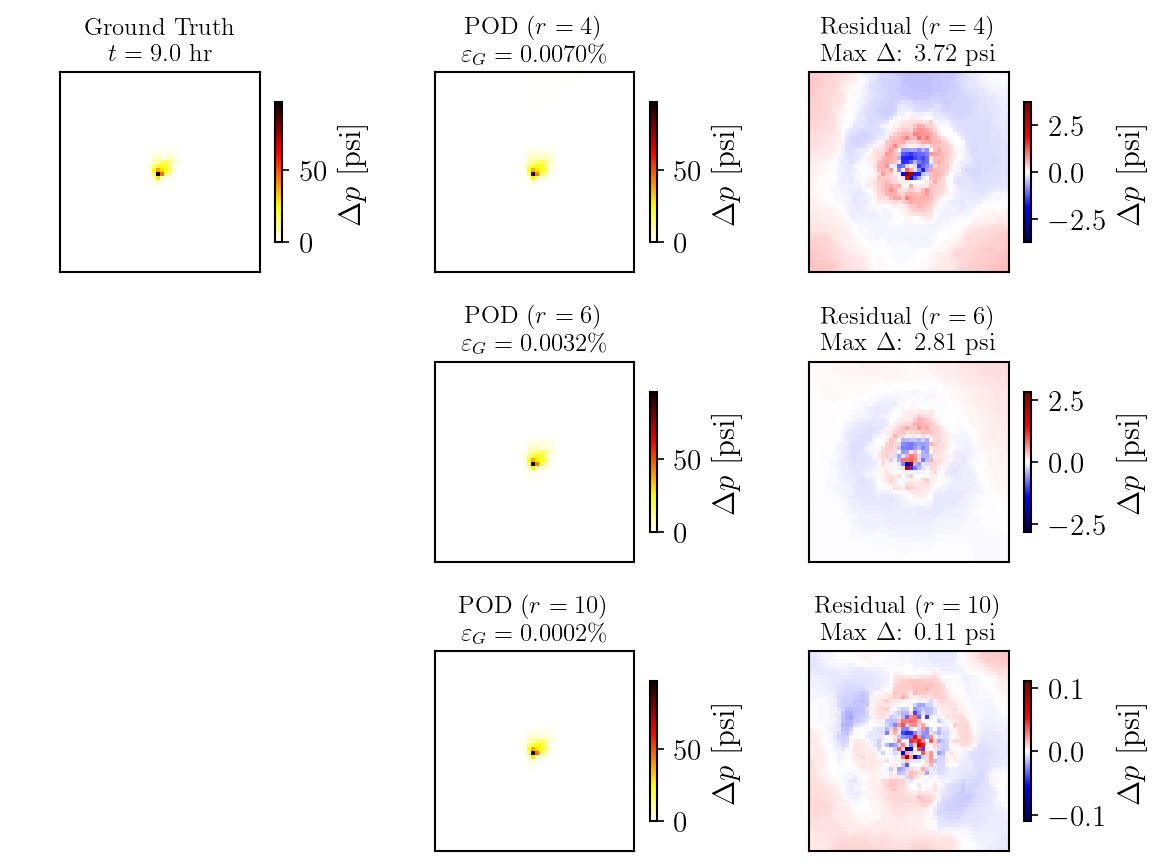

In [22]:
n_ranks = len(ranks)

fig, axes = plt.subplots(n_ranks, 3, figsize=(8, 6))

# ── snapshot time: mid-point of radial flow regime ────────────────────────
ki    = int(np.argmin(np.abs(t - t_rf_snap)))
F_gt  = dX[:, ki].reshape(ny, nx)
vm    = max(F_gt.max(), 0.1)

for ri, r in enumerate(ranks):

    X_r      = U[:, :r] @ np.diag(sv[:r]) @ Vt[:r, :] + X_mean
    dX_r     = (P['p_init_psia'] - X_r)[:, ki].reshape(ny, nx)
    diff     = F_gt - dX_r
    eps_step = (np.linalg.norm(X[:, ki] - X_r[:, ki]) /
                np.linalg.norm(X[:, ki]) * 100)
    vd       = max(np.abs(diff).max(), 0.01)

    # ── Column 0: Ground Truth (first row only) ───────────────────────────
    ax_gt = axes[ri, 0]
    if ri == 0:
        im1 = ax_gt.imshow(F_gt, origin='lower', cmap='hot_r', vmin=0, vmax=vm)
        ax_gt.set_title(rf'Ground Truth' + '\n' + rf'$t={t[ki]:.1f}$ hr', 
                        fontweight='normal', fontsize=12)
        #ax_gt.plot(nx//2, ny//2, 'w+', ms=7, mew=1.5)
        fig.colorbar(im1, ax=ax_gt, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)
        # overlay permeability contour to show heterogeneity context
        #ax_gt.contour(k_field, levels=[k_geo], colors=['cyan'],
                      #linewidths=0.6, alpha=0.5)
    else:
        ax_gt.axis('off')

    # ── Column 1: POD Reconstruction ──────────────────────────────────────
    ax_pod = axes[ri, 1]
    im2 = ax_pod.imshow(dX_r, origin='lower', cmap='hot_r', vmin=0, vmax=vm)
    ax_pod.set_title(rf'POD ($r={r}$)' + '\n' + rf'$\varepsilon_G={eps_step:.4f}\%$', 
                     fontweight='normal', fontsize=12)
    #ax_pod.plot(nx//2, ny//2, 'w+', ms=7, mew=1.5)
    fig.colorbar(im2, ax=ax_pod, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)

    # ── Column 2: Residual ─────────────────────────────────────────────────
    ax_res = axes[ri, 2]
    im3 = ax_res.imshow(diff, origin='lower', cmap='seismic', vmin=-vd, vmax=vd)
    ax_res.set_title(rf'Residual ($r={r}$)' + '\n' + rf'Max $\Delta$: {vd:.2f} psi', 
                     fontweight='normal', fontsize=12)
    #ax_res.plot(nx//2, ny//2, 'k+', ms=7, mew=1.5)
    fig.colorbar(im3, ax=ax_res, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)
    # overlay k_geo contour on residual — spatial correlation diagnostic
    #ax_res.contour(k_field, levels=[k_geo], colors=['k'],
                   #linewidths=0.6, alpha=0.4)

    for ax_obj in [ax_gt, ax_pod, ax_res]:
        if ax_obj.axison:
            ax_obj.set_xticks([]); ax_obj.set_yticks([])

plt.tight_layout()
sf('ch5_8_p_field_recon_case2.pdf')
plt.show()

---
## 9 · Reservoir Characterisation from ROM

The effective permeability $k_{eff}$ and skin $S$ are estimated from the ROM BHP at ranks $r \in \{3,5,10\}$ and compared against the simulator (ground truth) and the geometric-mean reference $k_{geo} = 20$ mD.

**Bourdet flat level:** $kh_{eff} = 70.6\,q\mu B_o/\Delta p'_{flat}$

**MTR slope:** $kh_{eff} = 162.6\,q\mu B_o/m$

**Skin factor:** $S = 1.1513\!\left[\Delta p_{1\,hr}/m - \log(k_{eff}/\phi\mu c_t r_w^2) + 3.2275\right]$

Note: for a strongly heterogeneous reservoir the PTA-derived $k_{eff}$ may depart from $k_{geo}$ depending on the well location and the spatial structure of the permeability field.

In [23]:
def characterise(dp_arr, t_arr, mtr_m, vs_m, label):
    dpr_arr  = bourdet(np.clip(dp_arr,0,None),t_arr,L=0.2)
    flat_val = np.median(dpr_arr[mtr_m&vs_m&(dpr_arr>0)])
    kh_b     = 70.6*q*mu*Bo/flat_val
    k_b      = kh_b/h_ft
    cf_r     = np.polyfit(np.log10(t_arr[mtr_m]),dp_arr[mtr_m],1)
    m_c      = cf_r[0]
    kh_s     = 162.6*q*mu*Bo/m_c
    k_s      = kh_s/h_ft
    dp_1hr   = float(np.interp(1.0,t_arr,dp_arr))
    S_c      = 1.1513*(dp_1hr/m_c
                       -np.log10(k_s/(phi_*mu*ct*rw**2))+3.2275)
    return dict(label=label,flat=flat_val,
                kh_b=kh_b,k_b=k_b,m=m_c,kh_s=kh_s,k_s=k_s,
                dp_1hr=dp_1hr,S=S_c)

res_sim=characterise(dp,t,mtr_mask,vs,'Simulator (GT)')
results=[res_sim]
for r in ranks:
    X_r     =U[:,:r]@np.diag(sv[:r])@Vt[:r,:]+X_mean
    bhp_r_wf=X_r[wc,:]-dp_correction
    dp_r    =P['p_init_psia']-bhp_r_wf
    dpr_r   =bourdet(np.clip(dp_r,0,None),t,L=0.2)
    vs_r    =mtr_mask&(dpr_r>1e-2)&(dp_r>1e-2)
    results.append(characterise(dp_r,t,mtr_mask,vs_r,f'ROM r={r}'))

W=15
print('='*95)
print(' RESERVOIR CHARACTERISATION — Case 2 (Highly Heterogeneous)')
print('='*95)
print(f'  k_geo={k_geo:.2f} mD  kh_geo={kh:.0f} mD-ft  S={S_true:.1f}  '
      f'V_DP={V_DP:.3f}  sigma_lnk={sigma_lnk:.3f}')
print()
hdr=f'{"":20s} {"k_geo(ref)":>{W}} '
hdr+=''.join([f'{r["label"]:>{W}} ' for r in results])
print(hdr); print('-'*95)

def row(lbl,key,fmt,ref):
    line=f'{lbl:<20s} {ref:>{W}{fmt}} '
    for res in results: line+=f'{res[key]:>{W}{fmt}} '
    print(line)

def row_err(lbl,key,ref):
    line=f'{lbl:<20s} {"—":>{W}} '
    for res in results:
        e=(res[key]-ref)/abs(ref)*100
        line+=f'{e:>{W}.2f} '
    print(line)

print('\n  -- BOURDET FLAT LEVEL --')
row('Δp\'_flat [psi]',   'flat','.4f',dp_flat)
row('kh (Bourdet)[mD-ft]','kh_b', '.2f',kh)
row('k_eff [mD]',          'k_b',  '.3f',k_geo)
row_err('  kh error [%]',     'kh_b', kh)
row_err('  k vs k_geo [%]', 'k_b',  k_geo)
print('\n  -- MTR SEMILOG SLOPE --')
row('m_slope[psi/cycle]',  'm',    '.4f',m_slope)
row('kh (slope)[mD-ft]',   'kh_s', '.2f',kh)
row('k_eff [mD]',           'k_s',  '.3f',k_geo)
row_err('  kh error [%]',     'kh_s', kh)
row_err('  k vs k_geo [%]', 'k_s',  k_geo)
print('\n  -- SKIN FACTOR --')
row('Δp at t=1hr [psi]',   'dp_1hr', '.3f',  float(np.interp(1.0,t,dp)))
row('Skin S [-]',            'S',    '.4f',S_true)
row_err('  S error [%]',     'S',          S_true)
print('='*95)

 RESERVOIR CHARACTERISATION — Case 2 (Highly Heterogeneous)
  k_geo=21.43 mD  kh_geo=3000 mD-ft  S=2.0  V_DP=0.848  sigma_lnk=1.887

                          k_geo(ref)  Simulator (GT)         ROM r=4         ROM r=6        ROM r=10 
-----------------------------------------------------------------------------------------------

  -- BOURDET FLAT LEVEL --
Δp'_flat [psi]               25.9808         24.2578         23.1108         24.6355         24.1409 
kh (Bourdet)[mD-ft]          3000.00         3213.08         3372.55         3163.82         3228.65 
k_eff [mD]                    21.429          21.421          22.484          21.092          21.524 
  kh error [%]                     —            7.10           12.42            5.46            7.62 
  k vs k_geo [%]                   —           -0.04            4.92           -1.57            0.45 

  -- MTR SEMILOG SLOPE --
m_slope[psi/cycle]           59.8368         55.7402         61.2141         56.2207         55.6513 
kh

---
## 10 · Summary of Results

| Quantity | Simulator | ROM | Theory / Reference | Error |
|----------|-----------|-----|-------------------|-------|
| Bourdet flat $\Delta p'$ [psi] | `flat_sim` | — | `dp_flat` | — |
| $kh_{eff}$ [mD-ft] | `kh_est` | — | `kh` | — |
| POD rank $r_{99.9\%}$ | — | `r999` | Case 1: 2–3 | — |
| Real-axis spread $\Delta\lambda$ | — | `lam_spread` | Case 1 ≈ 0.035 | — |
| $V_{DP}$ | — | — | 0.865 | — |
| Global $L^2$ error $\varepsilon_G$ | — | `eps_g`% | — | — |

In [24]:
import json as js
summary = dict(
    case='case2_heterogeneous',
    k_geo=float(k_geo), sigma_lnk=float(sigma_lnk), V_DP=float(V_DP),
    kh_true=float(kh), kh_est=float(kh_est),
    dp_flat_theory=float(dp_flat), dp_flat_sim=float(flat_sim),
    r_sel=int(r_sel), r999=int(r999),
    sigma1=float(sv[0]), sigma2_ratio=float(sn[1]),
    eps_global=float(eps_g),
    lam_spread=float(lam_spread),
    lambda_dom=float(lam[sidx[0]].real),
    tau_dom_hr=float(1/abs(omega[sidx[0]].real)),
    t_pss_hr=float(t_pss),
)
out_file = PROJECT/'data'/'processed'/'case2_summary.json'
with open(out_file,'w') as f:
    js.dump(summary,f,indent=2)

print('\n── SUMMARY ──────────────────────────────────────────────')
for k_,v_ in summary.items():
    print(f'  {k_:<25}: {v_}')
print(f'\nSaved: {out_file}')

NameError: name 'lam_spread' is not defined